In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------------------------
# Constantes de configuração do Dataset e Modelo
# ---------------------------------------------------------------
# O dataset possui 20 colunas de sensores. Para um IMU de 6 eixos + 5 flex,
# selecionamos exatamente os 11 canais fundamentais, descartando os 
# quatérnios e acelerações redundantes (body/world).
SELECTED_CHANNELS = [
    "flex_1", "flex_2", "flex_3", "flex_4", "flex_5", # 5 Sensores de Flexão
    "ACCx", "ACCy", "ACCz",                           # 3 Eixos de Aceleração Linear
    "GYRx", "GYRy", "GYRz"                            # 3 Eixos de Velocidade Angular
]

LABEL_COL        = "label"
SUBJECT_COL      = "subject"
WINDOW_SIZE      = 50
STRIDE_TRAIN     = 50   # sem sobreposição no treino → evita janelas quase idênticas
STRIDE_EVAL      = 25   # sobreposição só na avaliação (mais cobertura)
DELTA_THRESHOLD  = 0.002
N_CLASSES        = 40

# Caminho para a pasta onde os arquivos CSV extraídos do Figshare estão.
DATA_DIR = "/home/juan/Documentos/notebooks/ASL-Sensor-Dataglove-Dataset" 

# Fixar semente para reprodutibilidade dos resultados no artigo
np.random.seed(42)
tf.random.set_seed(42)

2026-05-29 12:27:16.984046: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-29 12:27:17.011393: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-29 12:27:17.137359: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-29 12:27:17.137396: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-29 12:27:17.159966: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
#outra celula gerada pela ia 
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

SELECTED_CHANNELS = [
    "flex_1", "flex_2", "flex_3", "flex_4", "flex_5",
    "ACCx", "ACCy", "ACCz",
    "GYRx", "GYRy", "GYRz"
]

LABEL_COL = "label"
SUBJECT_COL = "subject"
WINDOW_SIZE = 50
STRIDE = 25
DELTA_THRESHOLD = 0.02

def load_dataset(data_dir):
    frames = []
    for root, dirs, files in os.walk(data_dir):
        for fname in sorted(files):
            if fname.endswith(".csv"):
                file_path = os.path.join(root, fname)
                df = pd.read_csv(file_path)
                if LABEL_COL not in df.columns:
                    df[LABEL_COL] = fname.replace(".csv", "")
                if SUBJECT_COL not in df.columns:
                    df[SUBJECT_COL] = os.path.basename(root)
                df["source_file"] = fname
                frames.append(df)
    dataset = pd.concat(frames, ignore_index=True)
    dataset = dataset.dropna()
    return dataset

def split_by_subject(df, test_size=0.15, val_size=0.15, random_state=42):
    groups = df[SUBJECT_COL].values

    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    trainval_idx, test_idx = next(gss1.split(df, groups=groups))

    df_trainval = df.iloc[trainval_idx].reset_index(drop=True)
    df_test = df.iloc[test_idx].reset_index(drop=True)

    groups_trainval = df_trainval[SUBJECT_COL].values
    rel_val = val_size / (1.0 - test_size)

    gss2 = GroupShuffleSplit(n_splits=1, test_size=rel_val, random_state=random_state)
    train_idx, val_idx = next(gss2.split(df_trainval, groups=groups_trainval))

    df_train = df_trainval.iloc[train_idx].reset_index(drop=True)
    df_val = df_trainval.iloc[val_idx].reset_index(drop=True)

    return df_train, df_val, df_test


def extract_windows(df, channels, window_size=WINDOW_SIZE, stride=STRIDE, label_map=None):
    X_windows, y_windows = [], []

    for _, subj_df in df.groupby(SUBJECT_COL):
        values = subj_df[channels].values
        labels = subj_df[LABEL_COL].values

        for start in range(0, len(values) - window_size + 1, stride):
            end = start + window_size
            window_labels = labels[start:end]

            if len(np.unique(window_labels)) == 1:
                X_windows.append(values[start:end])
                y_windows.append(window_labels[0])

    X = np.array(X_windows, dtype=np.float32)
    y_raw = np.array(y_windows)

    if label_map is None:
        unique_labels = sorted(np.unique(y_raw))
        label_map = {lbl: idx for idx, lbl in enumerate(unique_labels)}

    y = np.array([label_map[lbl] for lbl in y_raw], dtype=np.int32)
    return X, y, label_map

def fit_normalizer(train_df, channels):
    scaler = StandardScaler()
    train_df = train_df.copy()
    train_df[channels] = scaler.fit_transform(train_df[channels])
    return scaler, train_df

def apply_normalizer(df, scaler, channels):
    df = df.copy()
    df[channels] = scaler.transform(df[channels])
    return df

In [3]:
# 1. Carrega os dados brutos (que já vêm separados por arquivo/gesto)
print("Carregando dataset...")
df_raw = load_dataset(DATA_DIR)

# 2. Faz a divisão de treino/validação/teste PRIMEIRO
print("Realizando particionamento LOSO...")
df_train_raw, df_val_raw, df_test_raw = split_by_subject(df_raw)

# 3. NORMALIZA DIRETO (Ignorando a filtragem de atividade!)
print("Normalizando dados...")
scaler, df_train_norm = fit_normalizer(df_train_raw, SELECTED_CHANNELS)
df_val_norm  = apply_normalizer(df_val_raw,  scaler, SELECTED_CHANNELS)
df_test_norm = apply_normalizer(df_test_raw, scaler, SELECTED_CHANNELS)

# 4. Extrai as janelas
print("Extraindo janelas temporais...")
X_train, y_train, label_map = extract_windows(df_train_norm, SELECTED_CHANNELS, stride=STRIDE_TRAIN)
X_val,   y_val,   _         = extract_windows(df_val_norm,   SELECTED_CHANNELS, stride=STRIDE_EVAL,  label_map=label_map)
X_test,  y_test,  _         = extract_windows(df_test_norm,  SELECTED_CHANNELS, stride=STRIDE_EVAL,  label_map=label_map)

print(f"Formato final Treino: {X_train.shape}")

Carregando dataset...
Realizando particionamento LOSO...
Normalizando dados...
Extraindo janelas temporais...
Formato final Treino: (20400, 50, 11)


In [4]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix

def build_mlp_model(timesteps, n_features, n_classes):
    inputs = keras.Input(shape=(timesteps, n_features))
    x = layers.Flatten()(inputs)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="MLP")

def build_cnn1d_model(timesteps, n_features, n_classes):
    inputs = keras.Input(shape=(timesteps, n_features))
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="CNN1D")

def build_lstm_model(timesteps, n_features, n_classes):
    inputs = keras.Input(shape=(timesteps, n_features))
    x = layers.LSTM(64, return_sequences=True)(inputs)
    x = layers.Dropout(0.4)(x)
    x = layers.LSTM(32)(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="LSTM")

def build_gru_model(timesteps, n_features, n_classes):
    inputs = keras.Input(shape=(timesteps, n_features))
    x = layers.GRU(64, return_sequences=True)(inputs)
    x = layers.Dropout(0.4)(x)
    x = layers.GRU(32)(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="GRU")

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, label_names, model_name):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            mode="min",
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=f"best_{model_name}.keras",
            monitor="val_loss",
            save_best_only=True,
            mode="min",
            verbose=1
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        verbose=1,
        callbacks=callbacks
    )

    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = np.mean(y_pred == y_test)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1w = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    f1m = f1_score(y_test, y_pred, average="macro", zero_division=0)

    report = classification_report(y_test, y_pred, target_names=label_names, zero_division=0, output_dict=True)
    cm = confusion_matrix(y_test, y_pred, normalize="true")

    results = {
        "model": model_name,
        "accuracy": acc,
        "precision_weighted": prec,
        "recall_weighted": rec,
        "f1_weighted": f1w,
        "f1_macro": f1m,
        "history": history.history,
        "report": report,
        "cm": cm
    }
    return results

In [6]:
label_names = [k for k, v in sorted(label_map.items(), key=lambda x: x[1])]

models = {
    "mlp": build_mlp_model(X_train.shape[1], X_train.shape[2], N_CLASSES),
    "cnn1d": build_cnn1d_model(X_train.shape[1], X_train.shape[2], N_CLASSES),
    "lstm": build_lstm_model(X_train.shape[1], X_train.shape[2], N_CLASSES),
    "gru": build_gru_model(X_train.shape[1], X_train.shape[2], N_CLASSES),
}

results = {}

for name, model in models.items():
    print(f"\n=== Treinando {name.upper()} ===")
    results[name] = evaluate_model(
        model, X_train, y_train, X_val, y_val, X_test, y_test, label_names, name
    )

2026-05-29 12:28:05.287585: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-29 12:28:05.290191: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



=== Treinando MLP ===
Epoch 1/50
620/638 [============================>.] - ETA: 0s - loss: 1.4114 - accuracy: 0.5569
Epoch 1: val_loss improved from inf to 0.71391, saving model to best_mlp.keras
638/638 [==============================] - 2s 2ms/step - loss: 1.3963 - accuracy: 0.5602 - val_loss: 0.7139 - val_accuracy: 0.7515 - lr: 0.0010
Epoch 2/50
625/638 [============================>.] - ETA: 0s - loss: 0.8055 - accuracy: 0.7172
Epoch 2: val_loss improved from 0.71391 to 0.62168, saving model to best_mlp.keras
638/638 [==============================] - 1s 2ms/step - loss: 0.8025 - accuracy: 0.7187 - val_loss: 0.6217 - val_accuracy: 0.7981 - lr: 0.0010
Epoch 3/50
623/638 [============================>.] - ETA: 0s - loss: 0.6970 - accuracy: 0.7511
Epoch 3: val_loss did not improve from 0.62168
638/638 [==============================] - 1s 2ms/step - loss: 0.6964 - accuracy: 0.7516 - val_loss: 0.6747 - val_accuracy: 0.7618 - lr: 0.0010
Epoch 4/50
626/638 [============================

In [8]:
def plot_histories(results):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for ax, (name, res) in zip(axes, results.items()):
        h = res["history"]
        ax.plot(h["loss"], label="Treino")
        ax.plot(h["val_loss"], label="Validação")
        ax.set_title(f"Loss - {name.upper()}")
        ax.set_xlabel("Época")
        ax.set_ylabel("Loss")
        ax.legend()

    plt.tight_layout()
    plt.show()

def plot_cm_grid(results, label_names, ncols=2):
    n = len(results)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 7*nrows))
    axes = np.array(axes).ravel()

    for ax, (name, res) in zip(axes, results.items()):
        sns.heatmap(res["cm"], ax=ax, cmap="Blues", vmin=0, vmax=1, cbar=False)
        ax.set_title(f"Matriz de Confusão - {name.upper()}")
        ax.set_xlabel("Predita")
        ax.set_ylabel("Real")

    for ax in axes[len(results):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [9]:
summary = []
for name, res in results.items():
    summary.append({
        "modelo": name.upper(),
        "acc": res["accuracy"],
        "prec_w": res["precision_weighted"],
        "rec_w": res["recall_weighted"],
        "f1_w": res["f1_weighted"],
        "f1_macro": res["f1_macro"],
    })

summary_df = pd.DataFrame(summary).sort_values("f1_macro", ascending=False)
summary_df

,modelo,acc,prec_w,rec_w,f1_w,f1_macro
1,CNN1D,0.794809,0.836457,0.794809,0.799155,0.799155
0,MLP,0.797034,0.819779,0.797034,0.788166,0.788166
3,GRU,0.787818,0.839309,0.787818,0.786892,0.786892
2,LSTM,0.746716,0.779218,0.746716,0.730982,0.730982


In [7]:
def plot_f1_compare(f1_by_model, label_names):
    n_models = len(f1_by_model)
    fig, axes = plt.subplots(n_models, 1, figsize=(18, 5 * n_models), sharex=True)

    if n_models == 1:
        axes = [axes]

    for ax, (model_name, f1_values) in zip(axes, f1_by_model.items()):
        order = np.argsort(f1_values)
        f1_sorted = f1_values[order]
        labels_sorted = [label_names[i] for i in order]

        ax.bar(range(len(f1_sorted)), f1_sorted, color=sns.color_palette("viridis", len(f1_sorted)))
        ax.axhline(np.mean(f1_sorted), ls="--", color="red", label=f"Média: {np.mean(f1_sorted):.3f}")
        ax.set_title(f"F1-score por classe — {model_name}")
        ax.set_ylabel("F1-score")
        ax.set_ylim(0, 1.05)
        ax.legend()

        ax.set_xticks(range(len(f1_sorted)))
        ax.set_xticklabels(labels_sorted, rotation=90)

    plt.xlabel("Classe")
    plt.tight_layout()
    plt.show()

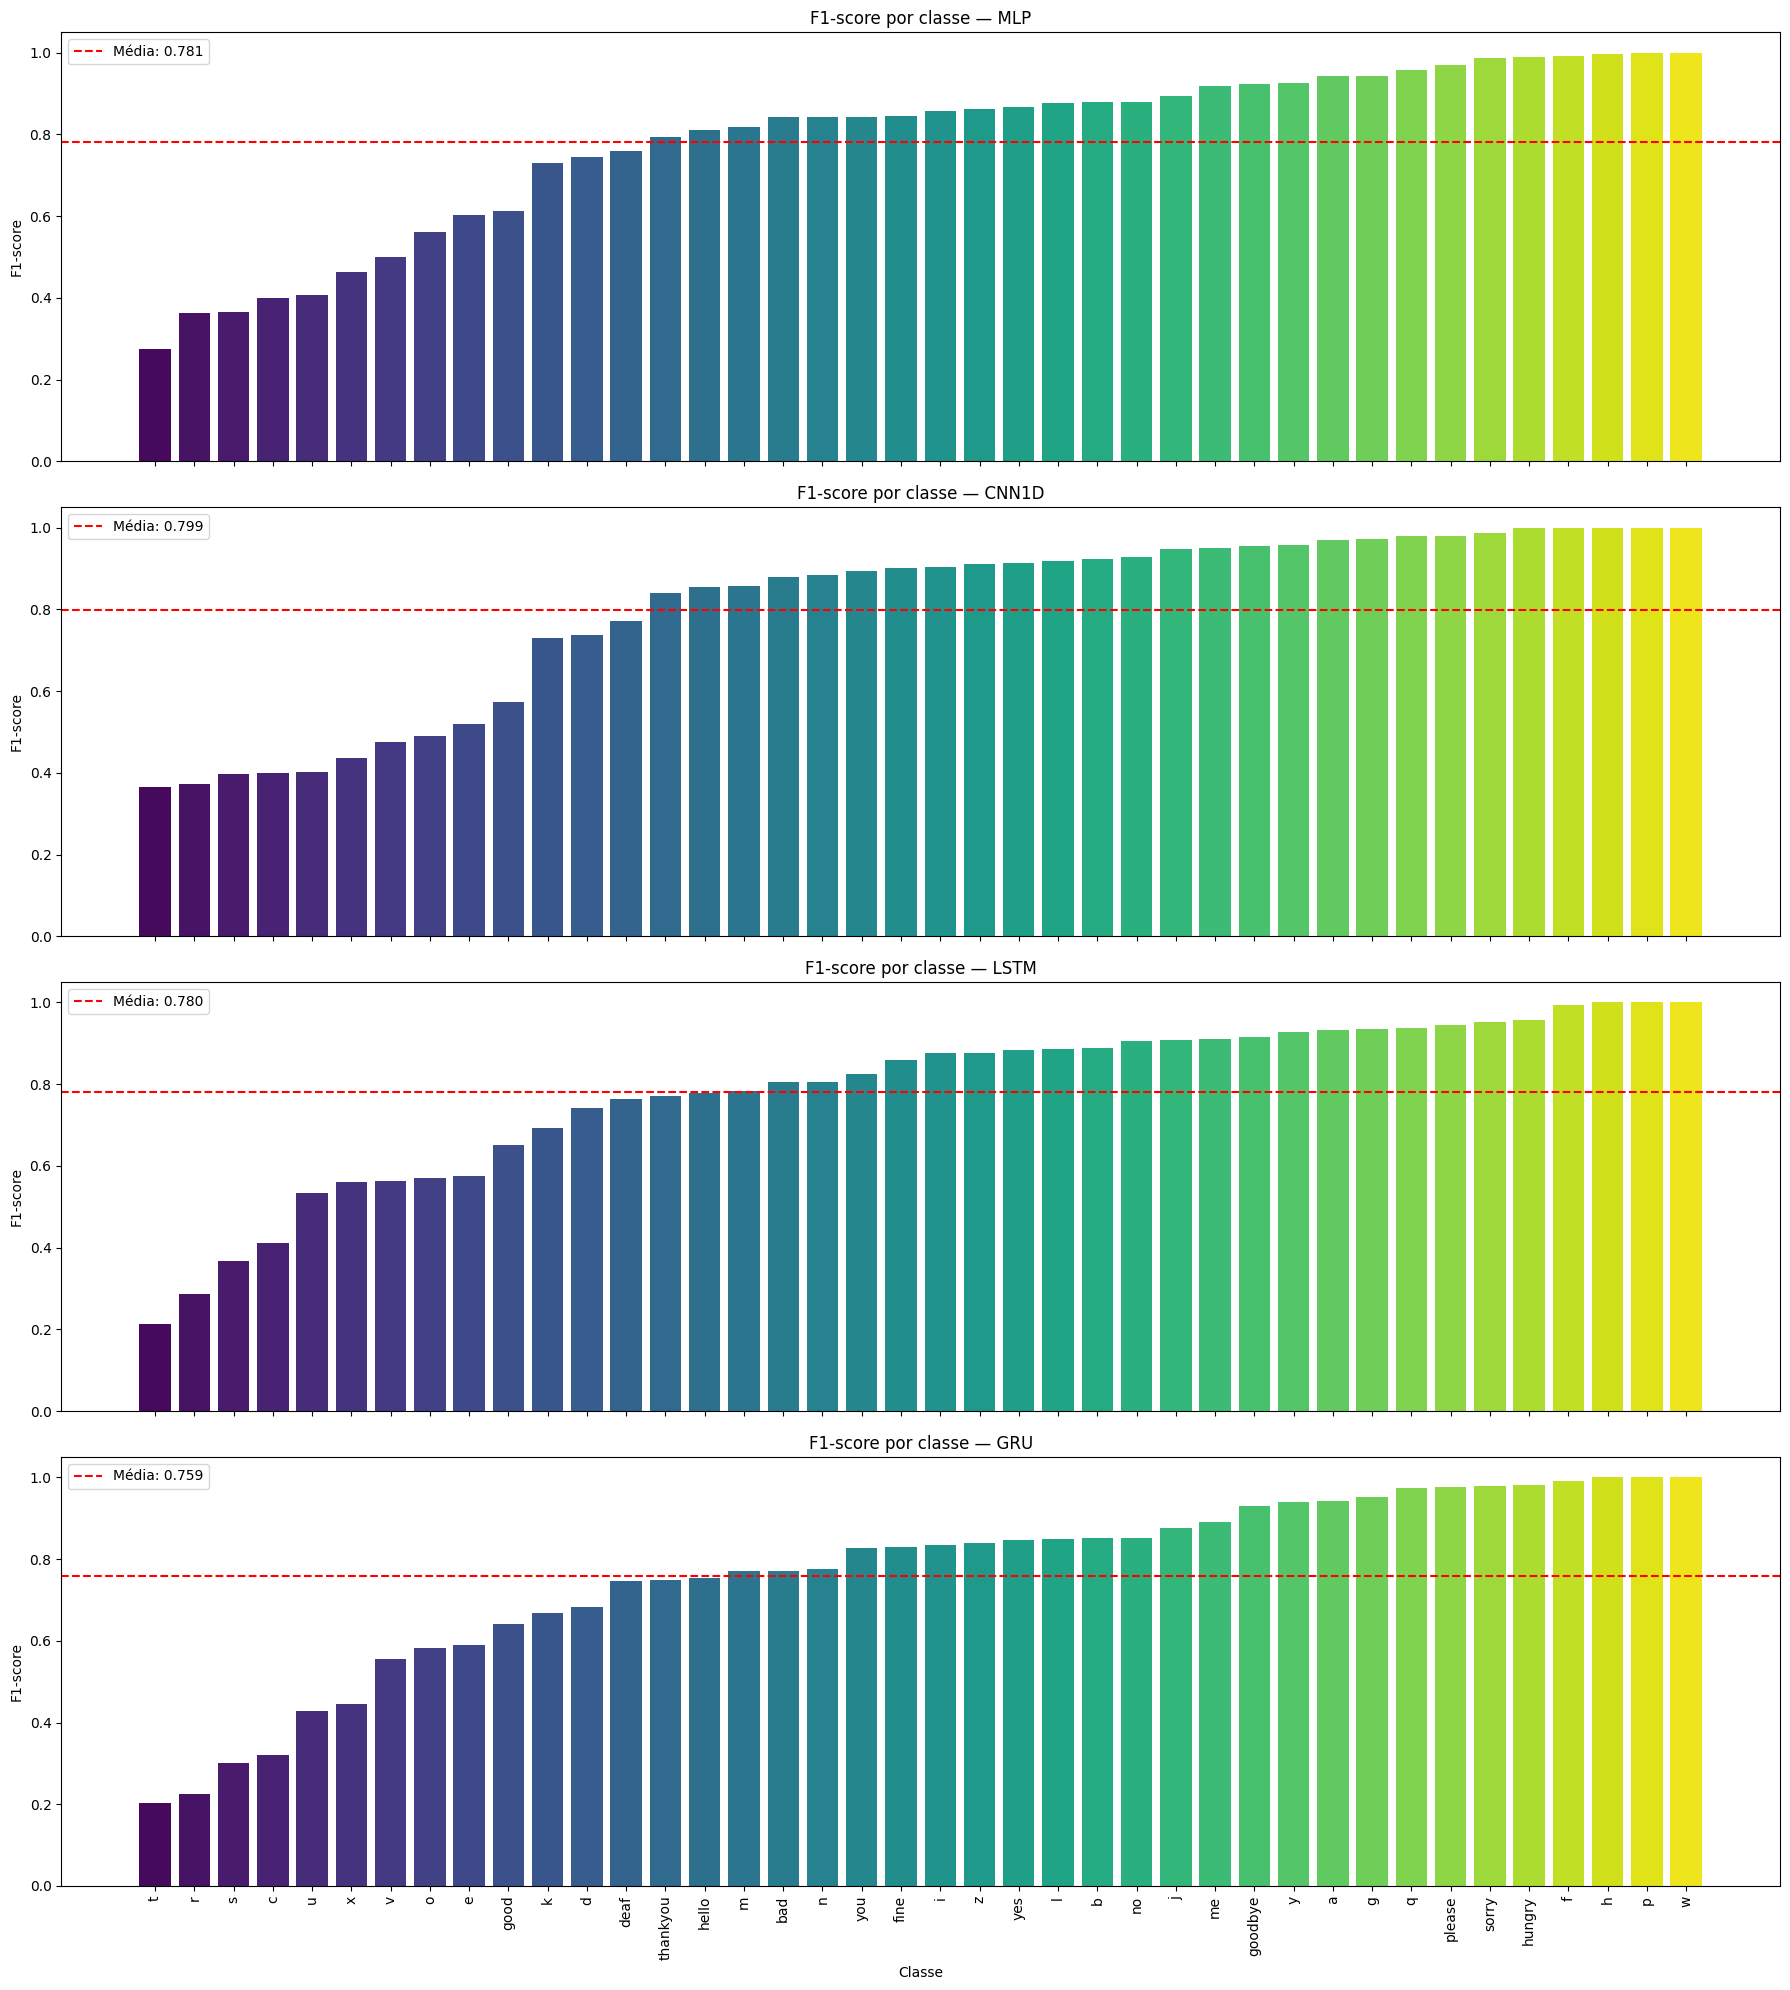

In [8]:
f1_by_model = {}

for name, res in results.items():
    f1_values = np.array([res["report"][cls]["f1-score"] for cls in label_names])
    f1_by_model[name.upper()] = f1_values

plot_f1_compare(f1_by_model, label_names)

In [9]:
def analisar_maiores_erros(cm, label_names, top_n=5):
    """Identifica os pares de gestos mais confundidos pelo modelo."""
    # Zerar a diagonal principal para focar apenas nos erros (falsos positivos/negativos)
    cm_errors = cm.copy()
    np.fill_diagonal(cm_errors, 0)
    
    # Obter os índices das maiores taxas de confusão
    indices = np.argsort(cm_errors, axis=None)[::-1]
    
    print(f"--- Top {top_n} Maiores Confusões ---")
    vistos = set()
    count = 0
    for idx in indices:
        if count >= top_n:
            break
        i, j = np.unravel_index(idx, cm_errors.shape)
        if cm_errors[i, j] > 0 and (i, j) not in vistos:
            print(f"Gesto Real: '{label_names[i]:<15}' confundido com '{label_names[j]:<15}' ({cm_errors[i, j]:.1%} das amostras reais)")
            vistos.add((i, j))
            count += 1

# Aplicando a análise no modelo escolhido como principal (ex: GRU)
melhor_modelo_nome = "gru"
print(f"\nAnálise de Erros para o modelo {melhor_modelo_nome.upper()}:")
analisar_maiores_erros(results[melhor_modelo_nome]["cm"], label_names, top_n=5)


Análise de Erros para o modelo GRU:
--- Top 5 Maiores Confusões ---
Gesto Real: 'r              ' confundido com 'u              ' (61.9% das amostras reais)
Gesto Real: 't              ' confundido com 'd              ' (61.4% das amostras reais)
Gesto Real: 'u              ' confundido com 'v              ' (50.0% das amostras reais)
Gesto Real: 's              ' confundido com 'e              ' (46.2% das amostras reais)
Gesto Real: 'c              ' confundido com 'e              ' (44.9% das amostras reais)


In [10]:
print("\n=== Análise de Tamanho e Memória dos Modelos (Foco em TinyML) ===")
for name, model in models.items():
    # Conta o número total de parâmetros treináveis
    trainable_params = np.sum([np.prod(v.get_shape()) for v in model.trainable_weights])
    
    # Estimativa de tamanho em SRAM (Peso Float32 padrão = 4 bytes por parâmetro)
    size_kb = (trainable_params * 4) / 1024
    
    # Estimativa de tamanho pós-quantização (INT8 = 1 byte por parâmetro)
    size_kb_quantizado = trainable_params / 1024
    
    print(f"Modelo: {name.upper():<7} | Parâmetros: {trainable_params:<7} | Estimativa Float32: {size_kb:>7.2f} KB | Quantizado (INT8): {size_kb_quantizado:>7.2f} KB")



=== Análise de Tamanho e Memória dos Modelos (Foco em TinyML) ===
Modelo: MLP     | Parâmetros: 184808  | Estimativa Float32:  721.91 KB | Quantizado (INT8):  180.48 KB
Modelo: CNN1D   | Parâmetros: 39528   | Estimativa Float32:  154.41 KB | Quantizado (INT8):   38.60 KB
Modelo: LSTM    | Parâmetros: 36584   | Estimativa Float32:  142.91 KB | Quantizado (INT8):   35.73 KB
Modelo: GRU     | Parâmetros: 28904   | Estimativa Float32:  112.91 KB | Quantizado (INT8):   28.23 KB

Contexto para o artigo (ESP32-S3 possui tipicamente 512KB de SRAM interna livre):
Observe qual modelo entrega o melhor balanço entre o F1-Score (Célula anterior) e o consumo de KB projetado acima.


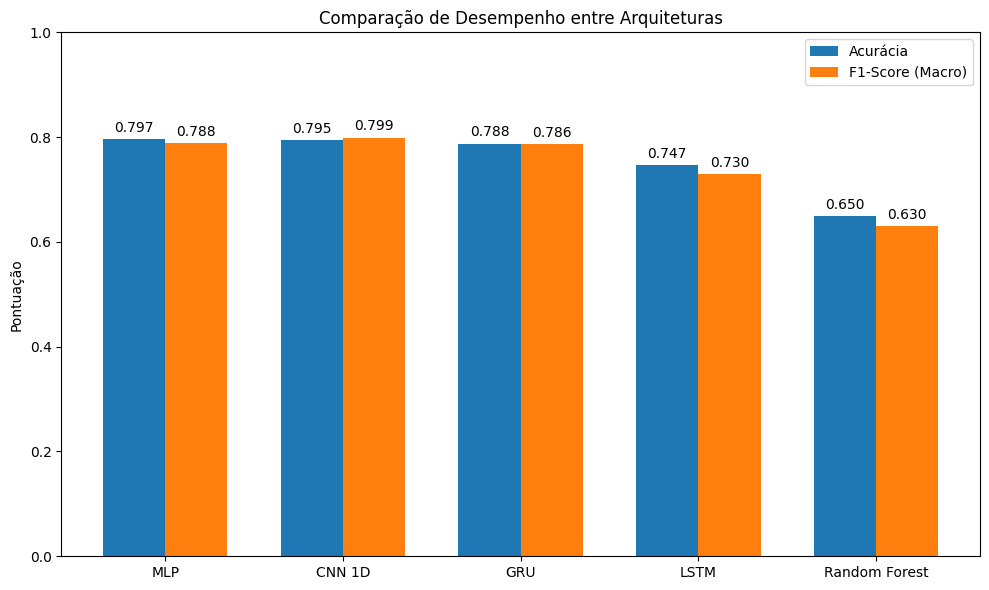

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Extraindo os dados do seu dicionário 'results' ou 'summary'
nomes_modelos = ["MLP", "CNN 1D", "GRU", "LSTM", "Random Forest"] # Adapte se necessário
# Substitua estas listas pelos valores reais que o seu código gerou ou extraia dinamicamente do seu DataFrame summary_df
acuracias = [0.7970, 0.7948, 0.7878, 0.7467, 0.6500] 
f1_macros = [0.7880, 0.7990, 0.7860, 0.7300, 0.6300]

x = np.arange(len(nomes_modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, acuracias, width, label='Acurácia', color='#1f77b4')
rects2 = ax.bar(x + width/2, f1_macros, width, label='F1-Score (Macro)', color='#ff7f0e')

ax.set_ylabel('Pontuação')
ax.set_title('Comparação de Desempenho entre Arquiteturas')
ax.set_xticks(x)
ax.set_xticklabels(nomes_modelos)
ax.set_ylim(0, 1.0)
ax.legend()

# Adicionando os valores em cima das barras
ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

fig.tight_layout()
plt.savefig('comparacao_modelos.png', dpi=300) # Salva a imagem em alta resolução para o Overleaf
plt.show()

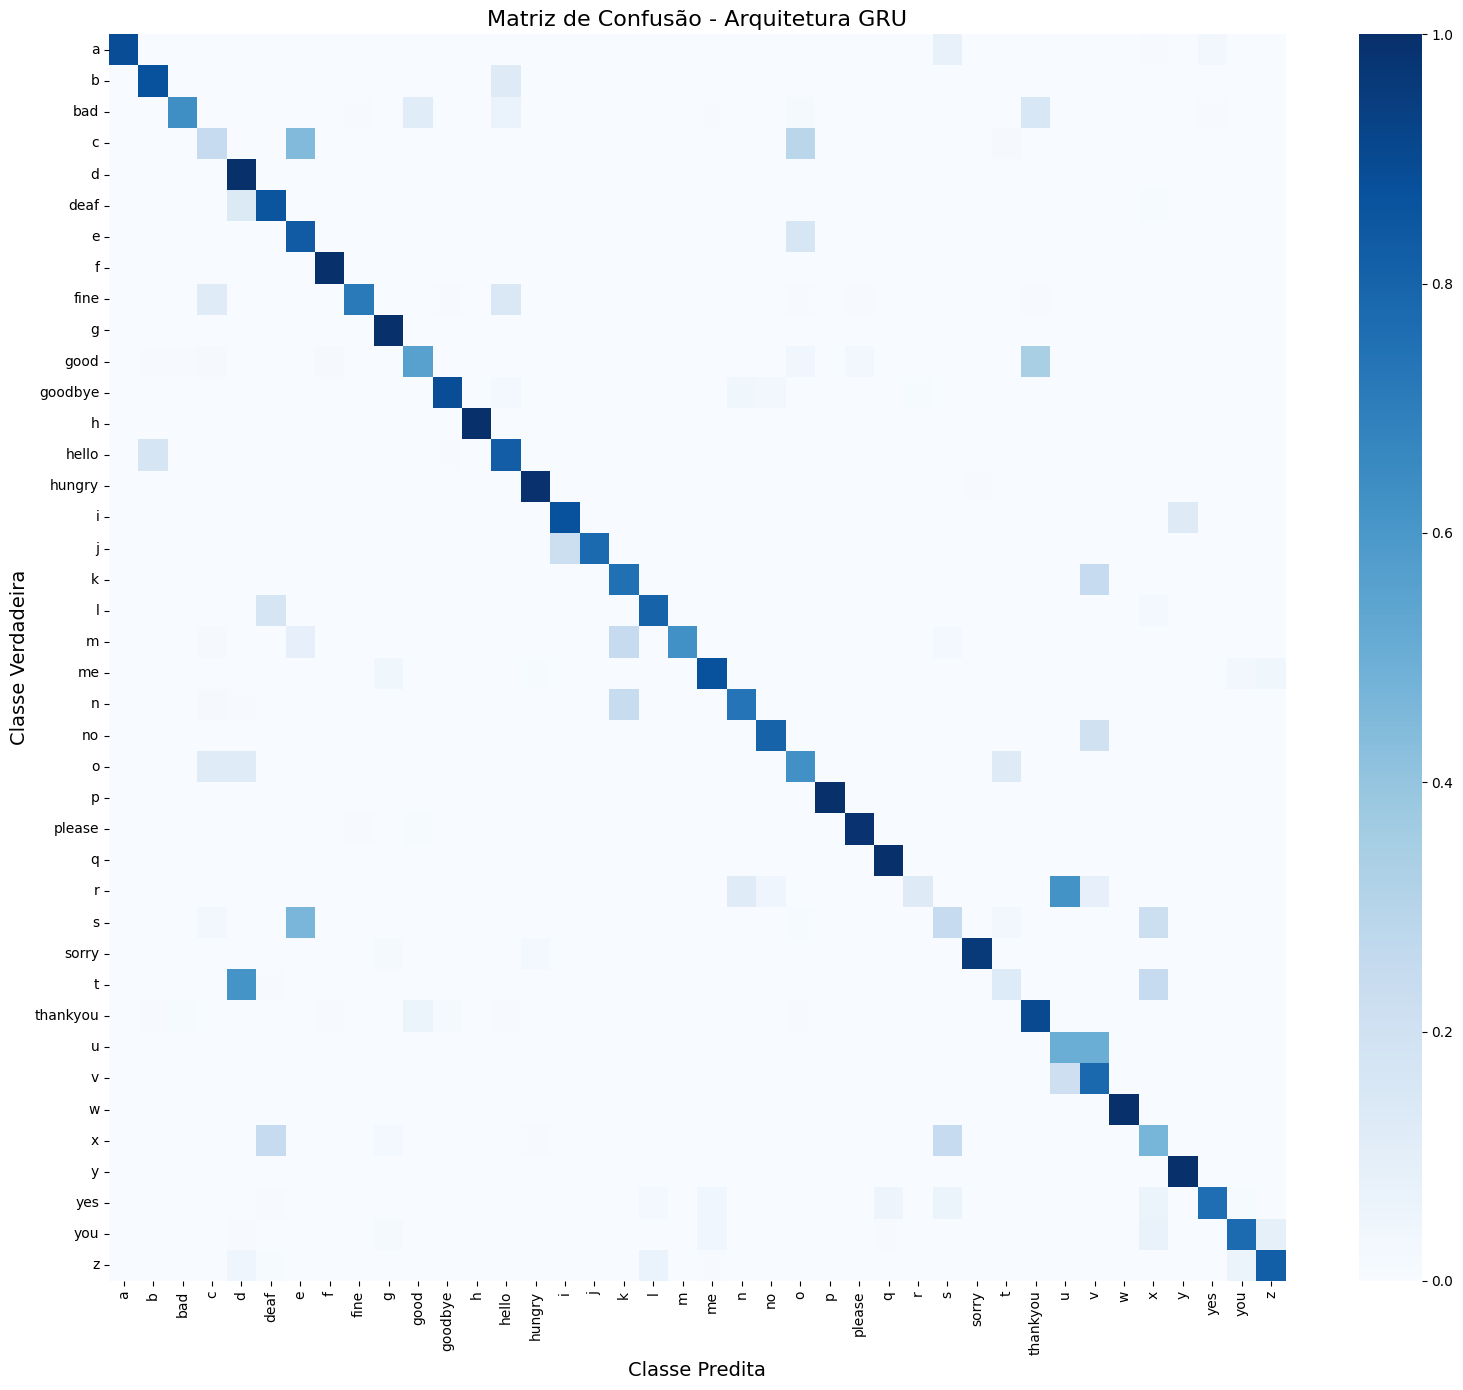

In [13]:
import seaborn as sns

# Pegando a matriz de confusão do modelo GRU (substitua pelo caminho correto no seu dict/variável)
cm_gru = results['gru']['cm'] 

plt.figure(figsize=(16, 14)) # Tamanho grande pois são 40 classes

# Plotando o mapa de calor. annot=False porque 40x40 números ficariam ilegíveis. 
# O padrão visual (cores) é o que importa para o artigo.
sns.heatmap(cm_gru, annot=False, cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names)

plt.title('Matriz de Confusão - Arquitetura GRU', fontsize=16)
plt.ylabel('Classe Verdadeira', fontsize=14)
plt.xlabel('Classe Predita', fontsize=14)

# Rotacionar os labels do eixo X para facilitar a leitura
plt.xticks(rotation=90) 
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('matriz_confusao_gru.png', dpi=300) # Salva para o Overleaf
plt.show()

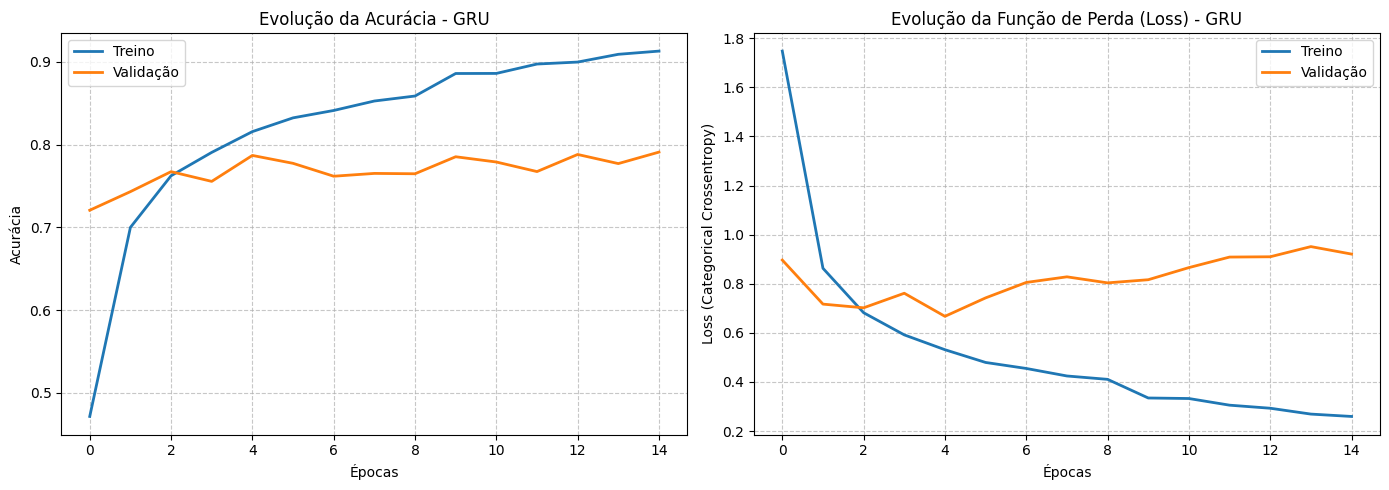

In [14]:
import matplotlib.pyplot as plt

# Acessando o histórico de treinamento do modelo GRU a partir do seu dicionário 'results'
historico = results['gru']['history']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Acurácia
ax1.plot(historico['accuracy'], label='Treino', linewidth=2)
ax1.plot(historico['val_accuracy'], label='Validação', linewidth=2)
ax1.set_title('Evolução da Acurácia - GRU')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Acurácia')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfico de Perda (Loss)
ax2.plot(historico['loss'], label='Treino', linewidth=2)
ax2.plot(historico['val_loss'], label='Validação', linewidth=2)
ax2.set_title('Evolução da Função de Perda (Loss) - GRU')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Loss (Categorical Crossentropy)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('curvas_aprendizado_gru.png', dpi=300) # Salva para o Overleaf
plt.show()